In [1]:
import freetype
import numpy as np

font_path = "../fonts/字悦九叠印篆.ttf"  # 替换为你的字体路径
face = freetype.Face(font_path)
face.set_pixel_sizes(0, face.units_per_EM)
face.load_char("好", freetype.FT_LOAD_RENDER | freetype.FT_LOAD_NO_HINTING)

bmp = face.glyph.bitmap
mask = np.array(bmp.buffer).reshape(bmp.rows, bmp.width) > 0

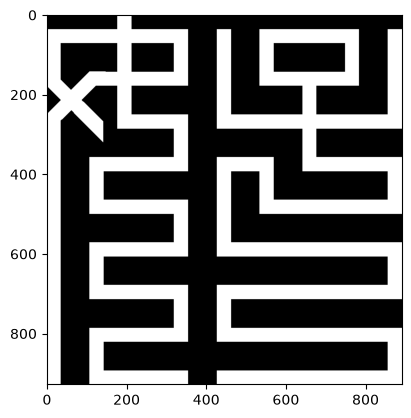

In [2]:
import matplotlib.pyplot as plt

plt.imshow(mask, cmap="gray")

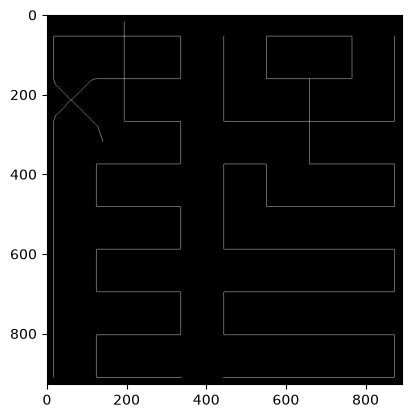

In [11]:
from skimage.morphology import skeletonize, medial_axis

skeleton = skeletonize(mask)
plt.imshow(skeleton, cmap="gray")

## Heuristic 1: co-dilation of positive and negative skeletons and find the meet point

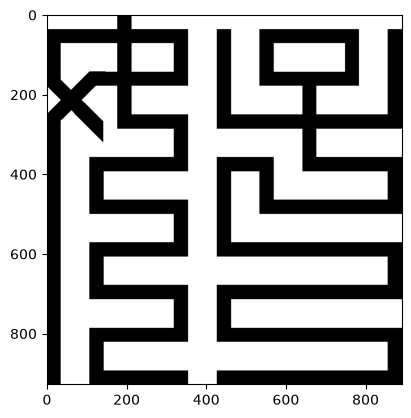

In [12]:
negative = ~mask
plt.imshow(negative, cmap="gray")

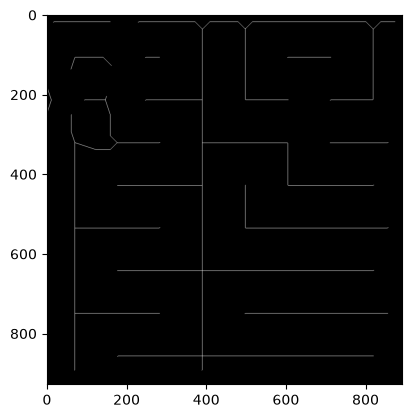

In [14]:
negative_skeleton = skeletonize(negative)
# negative_skeleton = medial_axis(negative, return_distance=False)
plt.imshow(negative_skeleton, cmap="gray")

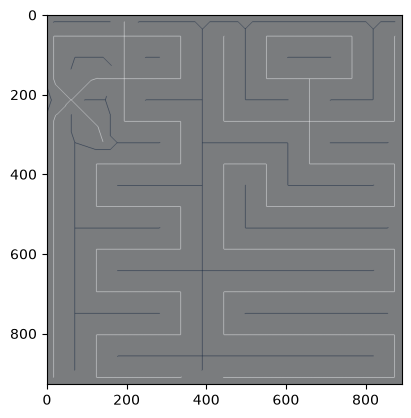

In [41]:
plt.imshow(skeleton, cmap="gray")
plt.imshow(negative_skeleton, cmap="Blues", alpha=0.5)

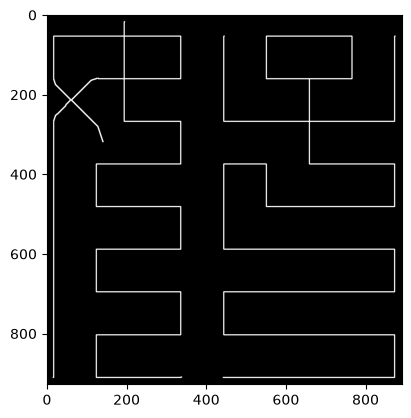

In [42]:
from scipy.ndimage import binary_dilation

kernel = np.ones((3, 3), dtype=bool)
dilated_skeleton = binary_dilation(skeleton, structure=kernel)
plt.imshow(dilated_skeleton, cmap="gray")

7


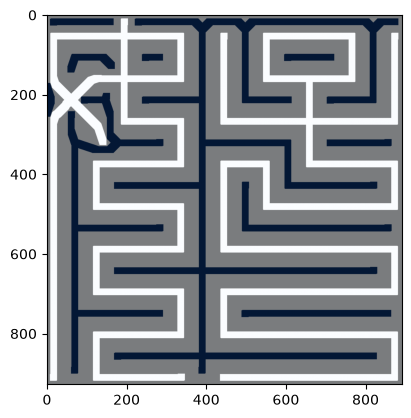

In [44]:
# dilate skeleton and negative skeleton at the same time, pixel by pixel, until two dilated skeletons touch each other.

width = 0
dilated_skeleton = skeleton.copy()
dilated_negative_skeleton = negative_skeleton.copy()
while True:
    dilated_skeleton = binary_dilation(dilated_skeleton, structure=kernel)
    dilated_negative_skeleton = binary_dilation(
        dilated_negative_skeleton, structure=kernel
    )
    overlap = np.logical_and(dilated_skeleton, dilated_negative_skeleton)
    if np.any(overlap):
        break
    width += 1
print(width)
plt.imshow(dilated_skeleton, cmap="gray")
plt.imshow(dilated_negative_skeleton, cmap="Blues", alpha=0.5)

conclusion: not good at skew lines.

## Heuristic 2: correct all strokes to strictly four directions: horizontal, vertical, diagonal and anti-diagonal.

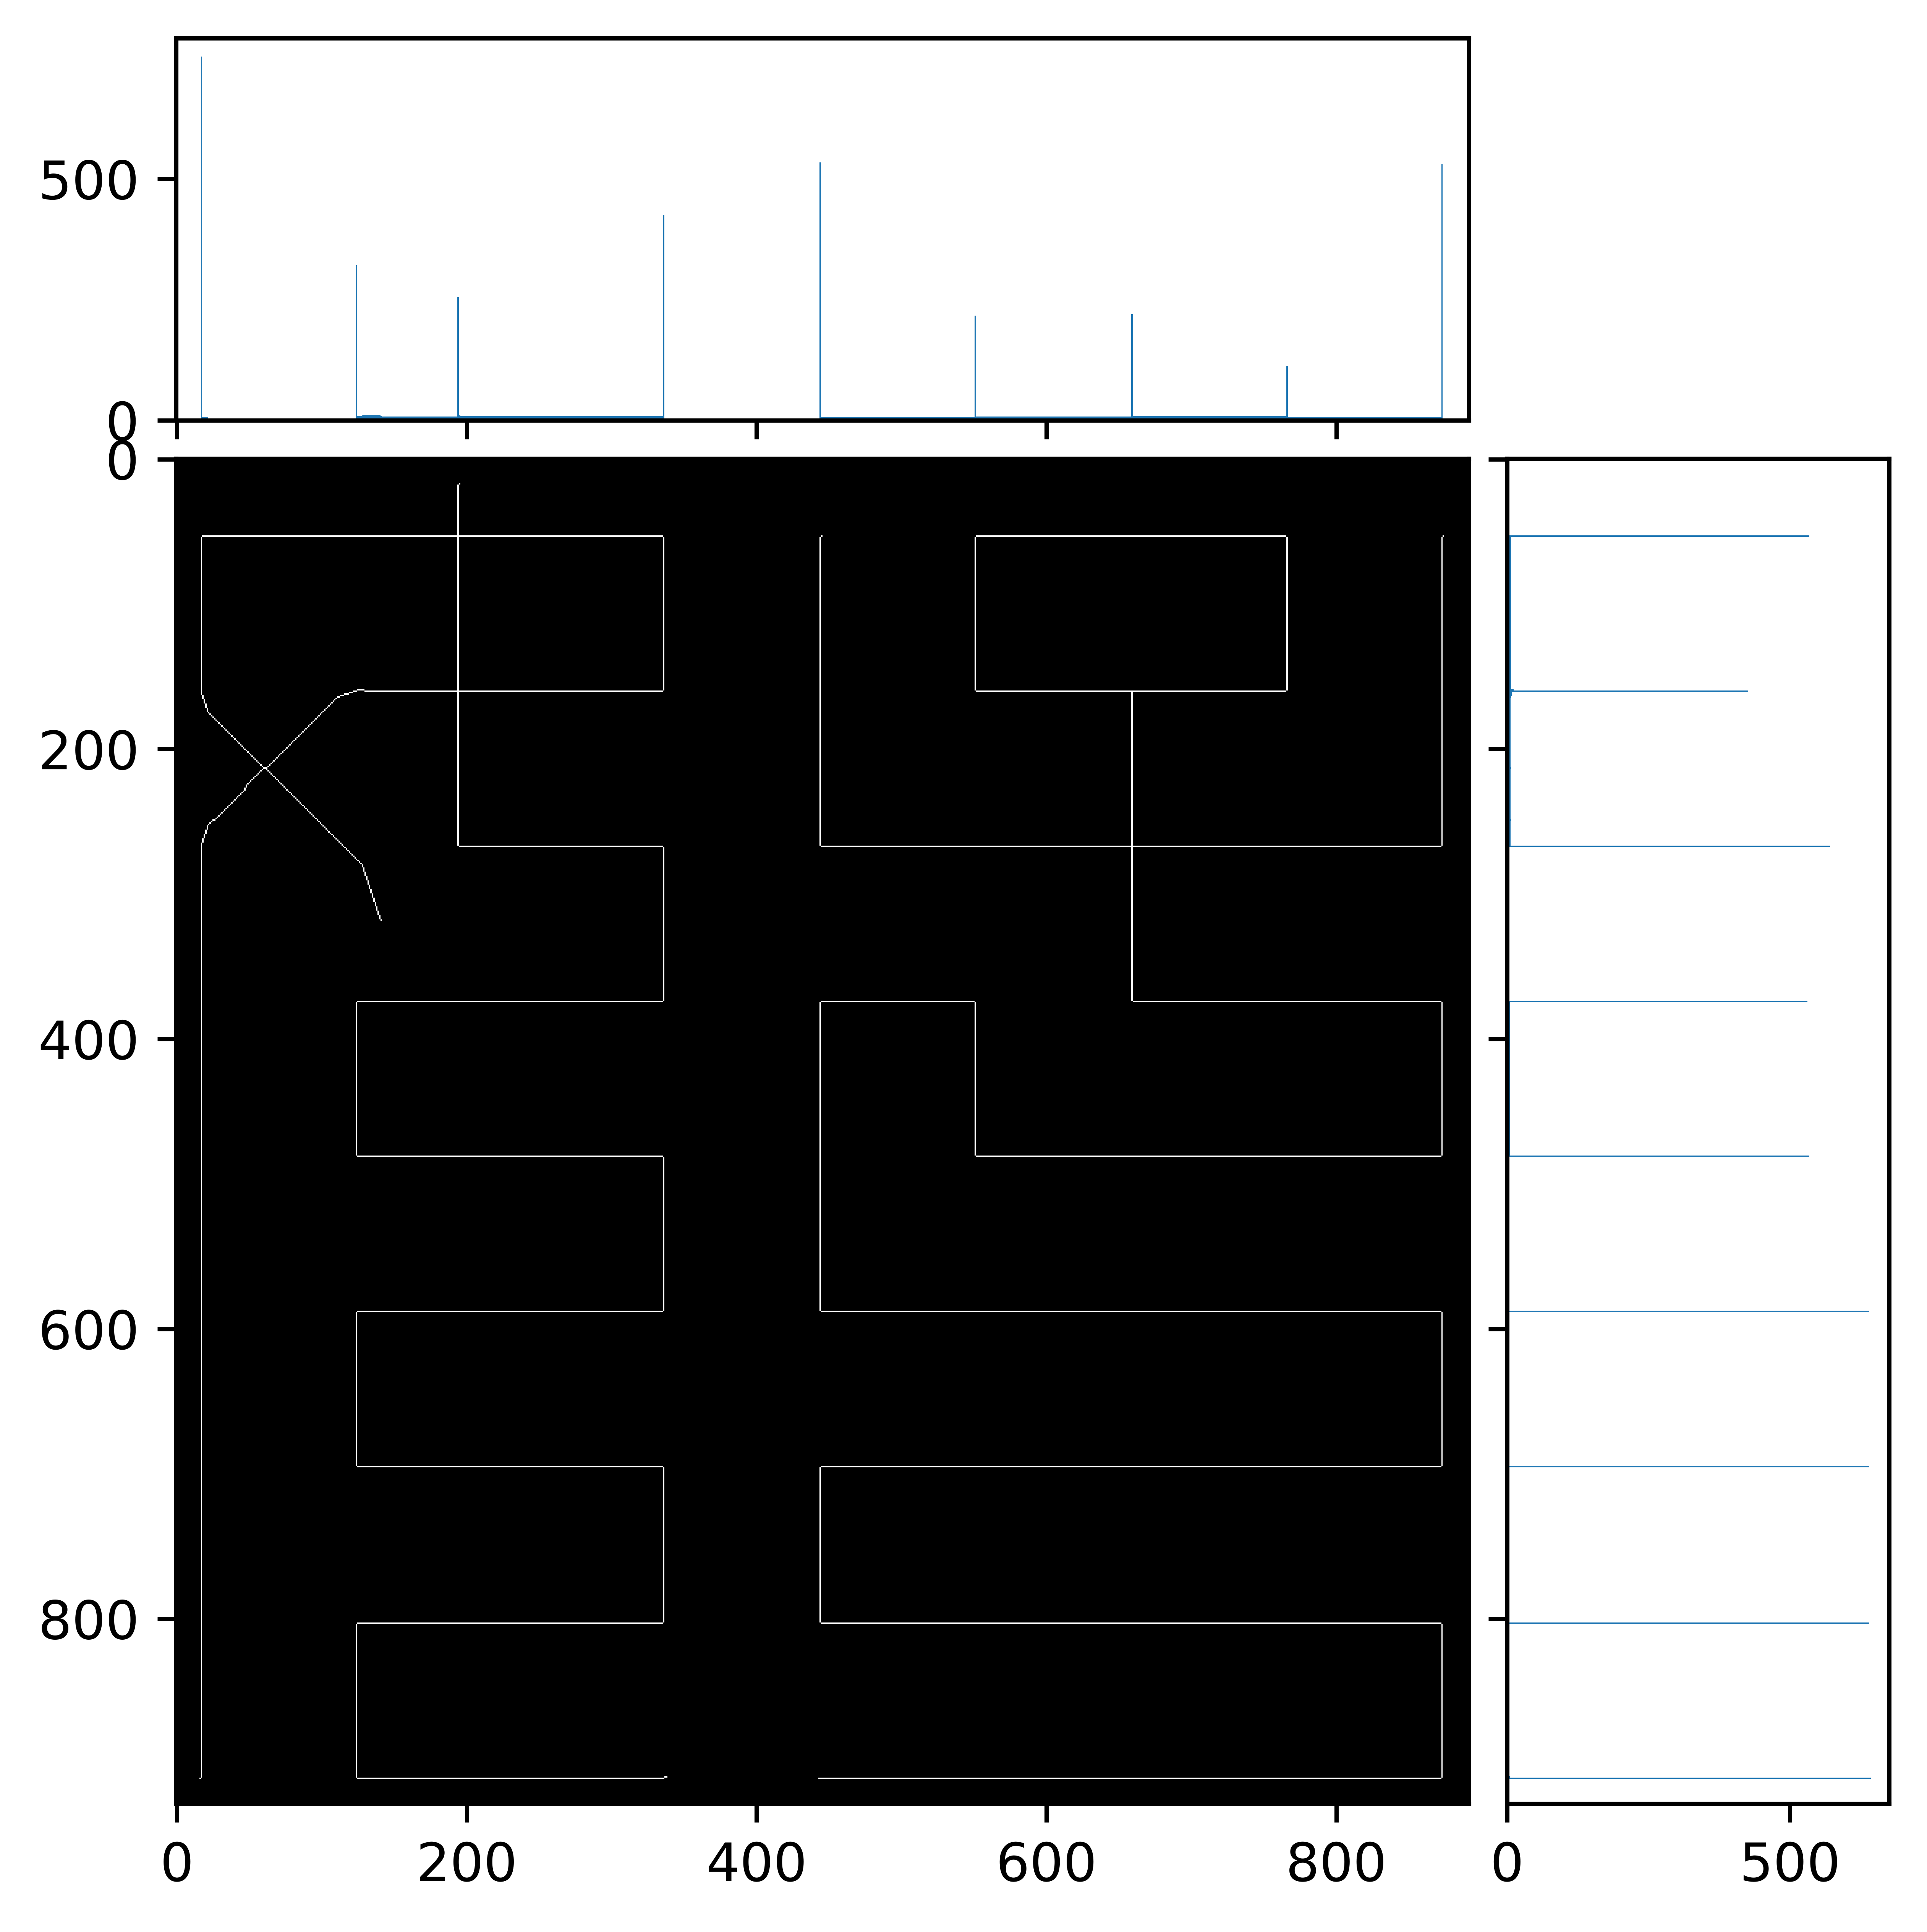

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

ys, xs = np.where(skeleton)

fig, ax = plt.subplots(figsize=(6, 6), dpi=1000)
ax.imshow(skeleton, cmap="gray")  # 默认 origin='upper'

divider = make_axes_locatable(ax)
ax_top = divider.append_axes("top", size=1.0, pad=0.1, sharex=ax)
ax_right = divider.append_axes("right", size=1.0, pad=0.1, sharey=ax)

# x histogram
hist_x = np.bincount(xs, minlength=skeleton.shape[1])
ax_top.bar(np.arange(len(hist_x)), hist_x, width=1.0)
ax_top.tick_params(labelbottom=False)

# y histogram
hist_y = np.bincount(ys, minlength=skeleton.shape[0])
ax_right.barh(np.arange(len(hist_y)), hist_y, height=1.0)

# 关键：由于 sharey，barh 已经与 imshow 对齐，不需要 invert_yaxis()

ax_right.tick_params(labelleft=False)

plt.show()

In [69]:
diag = xs - ys
hist_diag = np.bincount(diag - diag.min())
anti = xs + ys
hist_anti = np.bincount(anti)

plt.figure(figsize=(6, 6), dpi=len(hist_diag))
plt.bar(np.arange(len(hist_diag)), hist_diag)
plt.title("y=x direction")

Text(0.5, 1.0, 'y=x direction')

In [70]:
plt.figure(figsize=(6, 6), dpi=len(hist_anti))
plt.bar(np.arange(len(hist_anti)), hist_anti)
plt.title("y=-x direction")

Text(0.5, 1.0, 'y=-x direction')